Merged test cases: 17


,case,Dice_artery,Dice_vein,Dice_mean_AV,clDice_artery,clDice_vein,clDice_overall,clDice_mean_AV
0,case_005,0.921626,0.915694,0.918660,0.973459,0.967933,0.974790,0.970696
1,case_017,0.909174,0.929611,0.919392,0.960852,0.974806,0.972825,0.967829
2,case_052,0.932873,0.912355,0.922614,0.966809,0.954331,0.970787,0.960570
3,case_061,0.921078,0.912450,0.916764,0.944107,0.950910,0.957252,0.947508
4,case_099,0.920951,0.922694,0.921823,0.854907,0.869965,0.872383,0.862436
5,case_114,0.915174,0.906700,0.910937,0.907110,0.929799,0.923032,0.918454
6,case_125,0.926291,0.921063,0.923677,0.909245,0.934780,0.933155,0.922013
7,case_128,0.902440,0.899709,0.901074,0.856104,0.899616,0.893919,0.877860
8,case_129,0.914079,0.910327,0.912203,0.891147,0.924866,0.918399,0.908007
9,case_132,0.935297,0.921059,0.928178,0.873866,0.919319,0.908890,0.896592


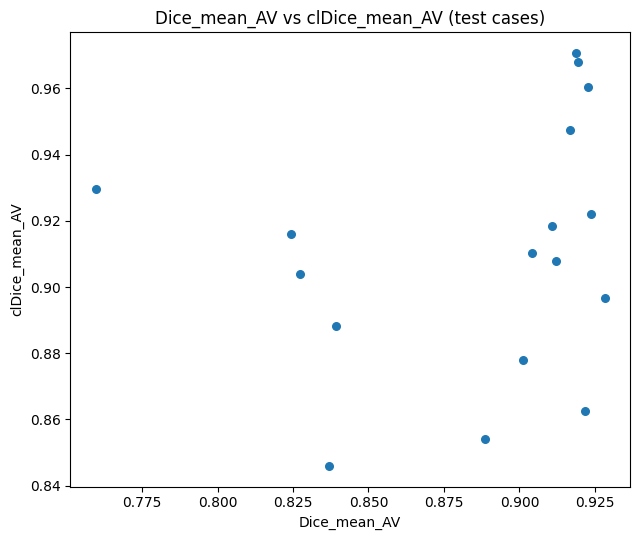

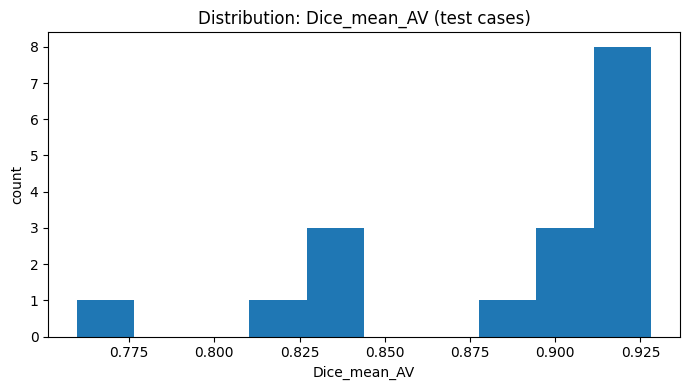

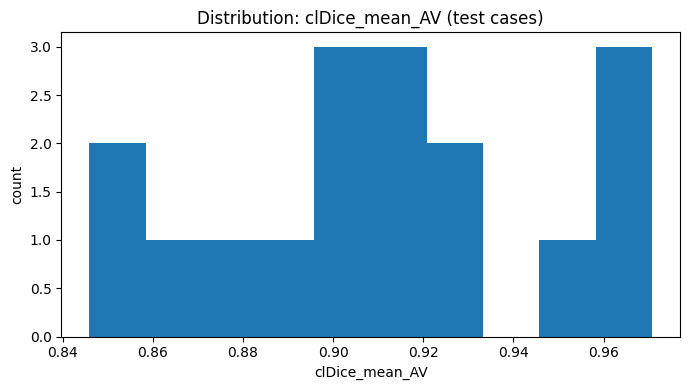

In [ ]:
# nnunet baseline
import json
import re
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
METRICS_JSON = Path("/projectnb/ec500kb/projects/Fall_2025_Projects/Project_4_VesselFM/data/nnUNet_results/Dataset001_nnunet/preds/ensemble_seed1-10/metrics.json")
CLDICE_JSON  = Path("/projectnb/ec500kb/projects/Fall_2025_Projects/Project_4_VesselFM/data/nnUNet_results/Dataset001_nnunet/preds/ensemble_seed1-10/cldice_eval/cldice_metrics.json")

CLASS_ID = {"artery": "1", "vein": "2"}

def load_json(path: Path):
    if path.exists():
        with path.open("r") as f:
            return json.load(f)
    alt = Path("/mnt/data") / path.name
    if alt.exists():
        with alt.open("r") as f:
            return json.load(f)
    raise FileNotFoundError(f"Not found: {path} (also tried {alt})")

def case_from_pred_path(pred_path: str) -> str:
    m = re.search(r"(case_\d+)", pred_path or "")
    if m:
        return m.group(1)
    s = Path(pred_path or "").name
    return s.replace(".nii.gz", "").replace(".nii", "") or "unknown"

def norm_case_name(s: str) -> str:
    return (s or "").replace(".nii.gz", "").replace(".nii", "")

metrics = load_json(METRICS_JSON)
cld = load_json(CLDICE_JSON)

dice_rows = []
for item in metrics.get("metric_per_case", []):
    met = item.get("metrics", {})
    a = met.get(CLASS_ID["artery"], {}) if isinstance(met, dict) else {}
    v = met.get(CLASS_ID["vein"], {}) if isinstance(met, dict) else {}
    case = case_from_pred_path(item.get("prediction_file", ""))
    da = a.get("Dice", None) if isinstance(a, dict) else None
    dv = v.get("Dice", None) if isinstance(v, dict) else None
    dice_rows.append({
        "case": case,
        "Dice_artery": da,
        "Dice_vein": dv,
        "Dice_mean_AV": (da + dv) / 2 if (da is not None and dv is not None) else None,
    })

cl_rows = []
for r in cld.get("per_case", []):
    cl_rows.append({
        "case": norm_case_name(r.get("case", "")),
        "clDice_artery": r.get("clDice_Artery"),
        "clDice_vein": r.get("clDice_Vein"),
        "clDice_overall": r.get("clDice_Overall"),
        "clDice_mean_AV": r.get("clDice_mean_AV"),
    })

df_dice = pd.DataFrame(dice_rows)
df_cldice = pd.DataFrame(cl_rows)

df = pd.merge(df_dice, df_cldice, on="case", how="inner")

order = [
    "case",
    "Dice_artery", "Dice_vein", "Dice_mean_AV",
    "clDice_artery", "clDice_vein", "clDice_overall", "clDice_mean_AV",
]
df = df[[c for c in order if c in df.columns]]

for c in [x for x in df.columns if x != "case"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.sort_values("case").reset_index(drop=True)

print(f"Merged test cases: {len(df)}")
display(df)

sc = df.dropna(subset=["Dice_mean_AV", "clDice_mean_AV"])

plt.figure(figsize=(6.5, 5.5))
plt.scatter(sc["Dice_mean_AV"], sc["clDice_mean_AV"], s=30)
plt.title("Dice_mean_AV vs clDice_mean_AV (test cases)")
plt.xlabel("Dice_mean_AV")
plt.ylabel("clDice_mean_AV")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(sc["Dice_mean_AV"].values, bins=10)
plt.title("Distribution: Dice_mean_AV (test cases)")
plt.xlabel("Dice_mean_AV")
plt.ylabel("count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(sc["clDice_mean_AV"].values, bins=10)
plt.title("Distribution: clDice_mean_AV (test cases)")
plt.xlabel("clDice_mean_AV")
plt.ylabel("count")
plt.tight_layout()
plt.show()


Merged test cases: 17


,case,Dice_artery,Dice_vein,Dice_mean_AV,clDice_artery,clDice_vein,clDice_overall,clDice_mean_AV
0,case_005,0.911539,0.914535,0.913037,0.970025,0.967191,0.973134,0.968608
1,case_017,0.912601,0.931135,0.921868,0.963696,0.974159,0.973833,0.968927
2,case_052,0.929449,0.913450,0.921449,0.956031,0.949102,0.962280,0.952566
3,case_061,0.915002,0.911546,0.913274,0.951686,0.955369,0.963353,0.953527
4,case_099,0.924753,0.923015,0.923884,0.863925,0.884830,0.884098,0.874377
5,case_114,0.904507,0.908906,0.906707,0.900278,0.926801,0.919230,0.913539
6,case_125,0.924919,0.918094,0.921506,0.904047,0.926885,0.928165,0.915466
7,case_128,0.907823,0.904539,0.906181,0.858073,0.902917,0.894414,0.880495
8,case_129,0.916045,0.912721,0.914383,0.897139,0.924542,0.922767,0.910840
9,case_132,0.936024,0.924254,0.930139,0.869248,0.913280,0.903297,0.891264


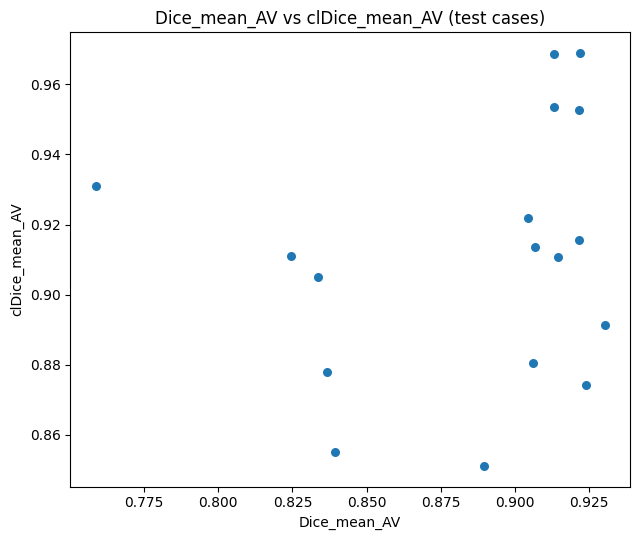

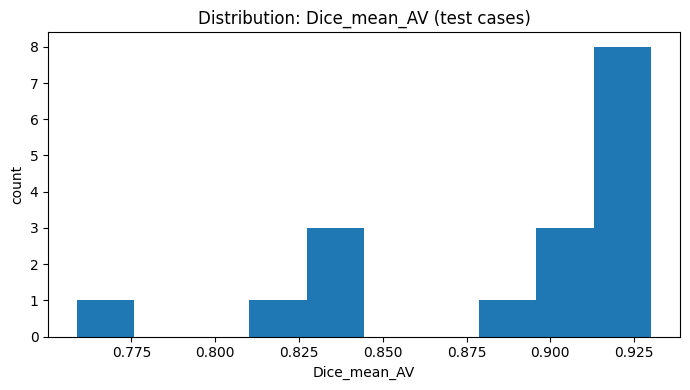

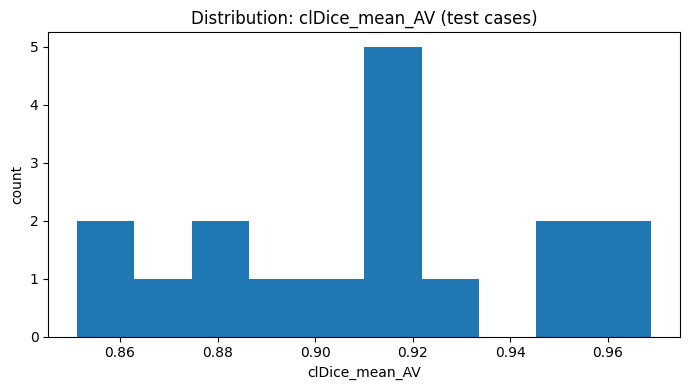

In [ ]:
# nnunet + vesselfm
import json
import re
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

METRICS_JSON = Path("/projectnb/ec500kb/projects/Fall_2025_Projects/Project_4_VesselFM/data/nnUNet_results/Dataset003_vesselfm_good/preds/ensemble_seed1-5/metrics.json")
CLDICE_JSON  = Path("/projectnb/ec500kb/projects/Fall_2025_Projects/Project_4_VesselFM/data/nnUNet_results/Dataset003_vesselfm_good/preds/ensemble_seed1-5/cldice_eval/cldice_metrics.json")

CLASS_ID = {"artery": "1", "vein": "2"}

def load_json(path: Path):
    if path.exists():
        with path.open("r") as f:
            return json.load(f)
    alt = Path("/mnt/data") / path.name
    if alt.exists():
        with alt.open("r") as f:
            return json.load(f)
    raise FileNotFoundError(f"Not found: {path} (also tried {alt})")

def case_from_pred_path(pred_path: str) -> str:
    m = re.search(r"(case_\d+)", pred_path or "")
    if m:
        return m.group(1)
    s = Path(pred_path or "").name
    return s.replace(".nii.gz", "").replace(".nii", "") or "unknown"

def norm_case_name(s: str) -> str:
    return (s or "").replace(".nii.gz", "").replace(".nii", "")

metrics = load_json(METRICS_JSON)
cld = load_json(CLDICE_JSON)

dice_rows = []
for item in metrics.get("metric_per_case", []):
    met = item.get("metrics", {})
    a = met.get(CLASS_ID["artery"], {}) if isinstance(met, dict) else {}
    v = met.get(CLASS_ID["vein"], {}) if isinstance(met, dict) else {}
    case = case_from_pred_path(item.get("prediction_file", ""))
    da = a.get("Dice", None) if isinstance(a, dict) else None
    dv = v.get("Dice", None) if isinstance(v, dict) else None
    dice_rows.append({
        "case": case,
        "Dice_artery": da,
        "Dice_vein": dv,
        "Dice_mean_AV": (da + dv) / 2 if (da is not None and dv is not None) else None,
    })

cl_rows = []
for r in cld.get("per_case", []):
    cl_rows.append({
        "case": norm_case_name(r.get("case", "")),
        "clDice_artery": r.get("clDice_Artery"),
        "clDice_vein": r.get("clDice_Vein"),
        "clDice_overall": r.get("clDice_Overall"),
        "clDice_mean_AV": r.get("clDice_mean_AV"),
    })

df_dice = pd.DataFrame(dice_rows)
df_cldice = pd.DataFrame(cl_rows)

df = pd.merge(df_dice, df_cldice, on="case", how="inner")

order = [
    "case",
    "Dice_artery", "Dice_vein", "Dice_mean_AV",
    "clDice_artery", "clDice_vein", "clDice_overall", "clDice_mean_AV",
]
df = df[[c for c in order if c in df.columns]]

for c in [x for x in df.columns if x != "case"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.sort_values("case").reset_index(drop=True)

print(f"Merged test cases: {len(df)}")
display(df)

sc = df.dropna(subset=["Dice_mean_AV", "clDice_mean_AV"])

plt.figure(figsize=(6.5, 5.5))
plt.scatter(sc["Dice_mean_AV"], sc["clDice_mean_AV"], s=30)
plt.title("Dice_mean_AV vs clDice_mean_AV (test cases)")
plt.xlabel("Dice_mean_AV")
plt.ylabel("clDice_mean_AV")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(sc["Dice_mean_AV"].values, bins=10)
plt.title("Distribution: Dice_mean_AV (test cases)")
plt.xlabel("Dice_mean_AV")
plt.ylabel("count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(sc["clDice_mean_AV"].values, bins=10)
plt.title("Distribution: clDice_mean_AV (test cases)")
plt.xlabel("clDice_mean_AV")
plt.ylabel("count")
plt.tight_layout()
plt.show()
